In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses warning messages
import tensorflow as tf


In [2]:
import numpy as np 
from matplotlib import pyplot as plt

from tensorflow.keras.preprocessing import image_dataset_from_directory

In [3]:
import os

data_dir = "/Users/ishitachoudhary/Desktop/Rugved/to_show/task7/anime_characters/"

# Get all file extensions in the dataset
extensions = set()

for subdir, _, files in os.walk(data_dir):
    #os.walk traverses over folders in a directory
    for file in files:
        ext = os.path.splitext(file)[-1].lower() #splits file name into name and extension
        extensions.add(ext)

print("File extensions found:", extensions)

File extensions found: {'', '.jpeg', '.png', '.jpg'}


In [4]:
import os
import imghdr


image_exts = ['jpeg', 'jpg', 'png', 'bmp'] 

for image_class in os.listdir(data_dir): #list of folders inside data_dir
    class_path = os.path.join(data_dir, image_class)
    
    if not os.path.isdir(class_path):
        print(f"Skipping non-directory: {class_path}")
        continue
    
    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        
        try:
            tip = imghdr.what(image_path) 
            if tip not in image_exts:
                print(f"Deleting: {image_path} (Detected as {tip})")
                os.remove(image_path)
        except Exception as e:
            print(f"⚠️ Issue but not removed: {image_path} | Error: {e}")



Skipping non-directory: /Users/ishitachoudhary/Desktop/Rugved/to_show/task7/anime_characters/.DS_Store


/var/folders/_l/qxqjj2kj4xg6gc7swf6c0d1w0000gn/T/ipykernel_74032/876561144.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
#load data
data=tf.keras.utils.image_dataset_from_directory('anime_characters')
#this is a tensorflow tensor/dataset. so we can't itterate over it directly using numpy

Found 812 files belonging to 10 classes.


In [6]:
#this data is only a generator, its not loaded to memory
data_iterator=data.as_numpy_iterator()

In [7]:
batch1=data_iterator.next()
batch1[0].shape
#1st batch- size 32
#batch1[1]-gives labels



(32, 256, 256, 3)

In [8]:
class_names = data.class_names
print(class_names)
#all labels according to how tensorflow function encoded y_train

['Elric Edward', 'Goku', 'Ichigo', 'Lelouch Lamperouge', 'Light Yagami', 'Luffy', 'Naruto', 'Sakata Gintoki', 'Sasuke', 'Zoro']


In [9]:
data = data.map(lambda x, y: (x / 255.0, y))
#normalization

In [10]:
data = data.shuffle(buffer_size=1000)  # Ensures randomization
train_size = int(len(data) * 0.8)

train = data.take(train_size)
test = data.skip(train_size)


In [11]:
print(len(train))
len(test)

20


6

In [12]:

train_iterator = train.as_numpy_iterator()
test_iterator = test.as_numpy_iterator()


x_train, y_train = [], []
for x, y in train_iterator:
    x_train.append(x)
    y_train.append(y)


x_test, y_test = [], []
for x, y in test_iterator:
    x_test.append(x)
    y_test.append(y)


In [13]:
x_train = np.concatenate(x_train, axis=0)
y_train = np.concatenate(y_train, axis=0)
x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
#list to numpy array

In [14]:
#we have x_train(640,256,256,3) and y_train(640,)
#x_test(172,256,256,3) and y_test(172)
def plot_sample(x,y,index):
    plt.figure(figsize=(5,5))
    plt.imshow(x[index])
    plt.xlabel(class_names[y[index]])


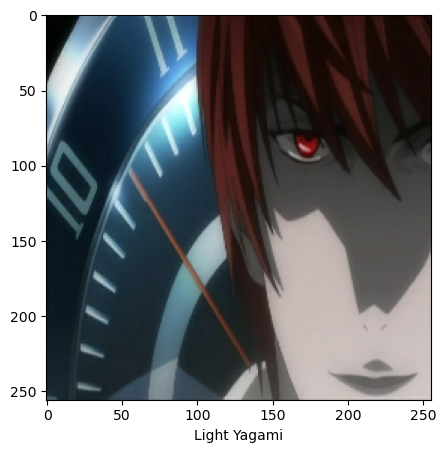

In [15]:
plot_sample(x_train,y_train,4)

In [16]:
from tensorflow.keras.models import Sequential
import tensorflow.keras.layers 

In [17]:

from tensorflow.keras import layers, models

num_classes = 10  
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001),input_shape=(256, 256, 3)), #32-no. of filters, 3x3- dimension of filters
    #third element of dimension of filter automatically matches 3rd element of image
    #(254,254,32)
    layers.MaxPooling2D(2,2), #default stride=dimensions=2
    
    #(127,127,32)
    
    layers.Conv2D(64, (3,3), activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)), #(125,125,64)
    layers.MaxPooling2D(2,2), #(62,62,64)

    layers.Conv2D(128, (3,3), activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)), #(60,60,128)
    layers.MaxPooling2D(2,2), #(30,30,128)

    layers.Flatten(), #FC (115200,)

    layers.Dense(128, activation='relu'), #(128,)
    layers.Dropout(0.5), #(128,)

    layers.Dense(num_classes, activation='softmax')  #(10,)
])
from tensorflow.keras.optimizers import Adam
# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if labels are one-hot encoded
              metrics=['accuracy'])

# Show model summary
model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,266 (56.61 MB)

 Trainable params: 14,840,266 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the model
history = model.fit(x_train, y_train, validation_split=0.2, epochs=50, batch_size=32)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 937ms/step - accuracy: 0.1042 - loss: 3.2027 - val_accuracy: 0.2177 - val_loss: 2.2625
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 823ms/step - accuracy: 0.2637 - loss: 2.1626 - val_accuracy: 0.3387 - val_loss: 2.0176
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4160 - loss: 1.8452 - val_accuracy: 0.4032 - val_loss: 1.7829
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5363 - loss: 1.4798 - val_accuracy: 0.4113 - val_loss: 1.7972
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 941ms/step - accuracy: 0.6505 - loss: 1.1308 - val_accuracy: 0.4194 - val_loss: 1.8479
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 783ms/step - accuracy: 0.7879 - loss: 0.8295 - val_accuracy: 0.4758 - val_loss: 1.7778
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 783ms/step - accuracy: 0.8226 - loss: 0.5966 - val_accuracy: 0.4839 - val_loss: 2.2187
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 792ms/step - accuracy: 0.9007 - loss: 0.4159 - val_accuracy: 

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=32)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.8208 - loss: 1.0303
